In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

import scSLAT
from scSLAT.model import Cal_Spatial_Net, load_anndatas, run_SLAT, spatial_match
from scSLAT.viz import match_3D_multi, hist, Sankey
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import torch
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D

/home/dbj/anaconda3/envs/scSLAT/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/dbj/anaconda3/envs/scSLAT/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/dbj/anaconda3/envs/scSLAT/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/dbj/anaconda3/envs/scSLAT/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/dbj/anaconda3/envs/scSLAT/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx f

In [4]:
adata=sc.read_visium('/home/dbj/mouse/DLPFC/DLPFC/151674/')
adata.var_names_make_unique()
import pandas as pd
truth = pd.read_csv('/home/dbj/mouse/vision/spatial/DLPFC_annotations/151674_truth.csv', sep='\t', index_col=0)
adata.obs['truth'] = truth.iloc[:,0]
adata = adata[~adata.obs['truth'].isna(), :]
adata1=adata

In [5]:
adata=sc.read_visium('/home/dbj/mouse/DLPFC/DLPFC/151673/')
adata.var_names_make_unique()
import pandas as pd
truth = pd.read_csv('/home/dbj/mouse/vision/spatial/DLPFC_annotations/151673_truth.csv', sep='\t', index_col=0)
adata.obs['truth'] = truth.iloc[:,0]
adata = adata[~adata.obs['truth'].isna(), :]
adata2=adata

In [6]:
Cal_Spatial_Net(adata1, k_cutoff=10, model='KNN')
Cal_Spatial_Net(adata2, k_cutoff=10, model='KNN')

Calculating spatial neighbor graph ...
The graph contains 37986 edges, 3634 cells.
10.452944413869014 neighbors per cell on average.
Calculating spatial neighbor graph ...
The graph contains 37480 edges, 3610 cells.
10.382271468144044 neighbors per cell on average.


In [7]:
edges, features = load_anndatas([adata1, adata2], feature='dpca',join='inner',check_order=False)

Use dpca feature to format graph
Warning! Dual PCA is using GPU, which may lead to OUT OF GPU MEMORY in big dataset!


In [8]:
embd0, embd1, time = run_SLAT(features, edges)

Choose GPU:0 as device
Running
Training model time: 0.95


In [9]:
best, index, distance = spatial_match([embd0, embd1], adatas=[adata1,adata2], reorder=False)

In [10]:
adata1_df = pd.DataFrame({'index': range(embd0.shape[0]),
                        'x': adata1.obsm['spatial'][:,0],
                        'y': adata1.obsm['spatial'][:,1],
                        'celltype': adata1.obs['truth']})
adata2_df = pd.DataFrame({'index': range(embd1.shape[0]),
                        'x': adata2.obsm['spatial'][:,0],
                        'y': adata2.obsm['spatial'][:,1],
                        'celltype': adata2.obs['truth']})

matching = np.array([range(index.shape[0]), best])
best_match = distance[:,0]

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# Normalize the x and y coordinates to the range [0, 1]
def normalize_coordinates(df):
    df[['x', 'y']] = (df[['x', 'y']] - df[['x', 'y']].min()) / (df[['x', 'y']].max() - df[['x', 'y']].min())
    return df

adata1_df = normalize_coordinates(adata1_df)
adata2_df = normalize_coordinates(adata2_df)

In [13]:
def plot_matching_flow(
    adata1_df, adata2_df, matching, selected_cell_type, 
    arrow_sample_size_per_type=55, xlim=(0, 1), ylim=(0, 1), height_scale=1.0, save_path=None
):

    fig = plt.figure(figsize=(14, 7))
    ax = fig.add_subplot(111, projection="3d")
    
    matched_indices_adata1 = matching[0]  
    matched_indices_adata2 = matching[1]  
    
    pcloud1 = adata1_df[['x', 'y']].values 
    pcloud2 = adata2_df[['x', 'y']].values  
    adata1_df['celltype'] = adata1_df['celltype'].astype(str)
    adata2_df['celltype'] = adata2_df['celltype'].astype(str)
    celltypes_adata1 = adata1_df['celltype'].values
    celltypes_adata2 = adata2_df['celltype'].values
    
    unique_celltypes_adata1 = np.unique(celltypes_adata1)
    unique_celltypes_adata2 = np.unique(celltypes_adata2)
    unique_celltypes_combined = np.unique(np.concatenate([unique_celltypes_adata1, unique_celltypes_adata2]))

    # Create the color map for the combined unique cell types
    color_map_combined = {celltype: cm.tab20(i / len(unique_celltypes_combined)) 
                          for i, celltype in enumerate(unique_celltypes_combined)}
    
    # Map the colors to the original datasets
    color_map_adata1 = {celltype: color_map_combined[celltype] for celltype in unique_celltypes_adata1}
    color_map_adata2 = {celltype: color_map_combined[celltype] for celltype in unique_celltypes_adata2}

    ax.scatter(
        pcloud2[:, 0], pcloud2[:, 1], np.zeros(pcloud2.shape[0]),c=[color_map_adata2[celltype] for celltype in celltypes_adata2], s=1, alpha=0.6)
    
    ax.scatter(
        pcloud1[:, 0], pcloud1[:, 1], np.ones(pcloud1.shape[0]) * height_scale,c=[color_map_adata1[celltype] for celltype in celltypes_adata1], s=1, alpha=0.6)

    
    # Highlight start points for the selected cell type
    selected_indices_adata1 = np.where(celltypes_adata1 == selected_cell_type)[0]
    blue_points=[]
    valid_pairs = []
    endpoint_labels = []
    for i in range(matching.shape[1]):
        pair = matching[:, i] 
        celltype1 = adata1_df.loc[adata1_df["index"] == pair[1], "celltype"].values[0]
        celltype2 = adata2_df.loc[adata2_df["index"] == pair[0], "celltype"].values[0]
        
        if celltype2 == selected_cell_type:
            valid_pairs.append(pair)
            endpoint_labels.append(celltype1)
    pcloud2_coords = np.array([pcloud2[pair[0]] for pair in valid_pairs])
    pcloud1_coords = np.array([pcloud1[pair[1]] for pair in valid_pairs])
    blue_points.extend([pcloud1[pair[1]] for pair in valid_pairs])
    x_pcloud2 = pcloud2_coords[:, 0]
    y_pcloud2 = pcloud2_coords[:, 1]
    x_pcloud1 = pcloud1_coords[:, 0]
    y_pcloud1 = pcloud1_coords[:, 1]
    ax.scatter(x_pcloud2, y_pcloud2, np.zeros_like(x_pcloud2), c="red", s=2, alpha=1)
    ax.scatter(x_pcloud1, y_pcloud1, np.full_like(x_pcloud1, height_scale), c="blue", s=6, alpha=1)
    
    for i in range(len(valid_pairs)):
        ax.plot(
            [pcloud2[valid_pairs[i][0], 0], pcloud1[valid_pairs[i][1], 0]],
            [pcloud2[valid_pairs[i][0], 1], pcloud1[valid_pairs[i][1], 1]],
            [0, height_scale],
            color="grey", linewidth=0.6, alpha=0.5, linestyle="--"
        )

    ax.view_init(elev=30, azim=-15)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(0, 2 * height_scale)
    ax.set_title("")
    ax.set_axis_off()
    # ax.legend()  # Remove legend
    if save_path:
        fig.savefig(save_path, dpi=300)
        print(f"Image saved as: {save_path}")

    plt.tight_layout()
    plt.show()
    return np.array(blue_points),np.array(endpoint_labels)

In [14]:
def chamfer_distance(points_a, points_b):
    dists_a_to_b = np.min(np.linalg.norm(points_a[:, np.newaxis] - points_b, axis=2), axis=1)
    dists_b_to_a = np.min(np.linalg.norm(points_b[:, np.newaxis] - points_a, axis=2), axis=1)
    
    return np.mean(dists_a_to_b**2) + np.mean(dists_b_to_a**2)

In [15]:
def calculate_prediction_accuracy(end_labels, expected_end_type):
    total_predictions = len(end_labels)
    is_correct_mask = np.isin(end_labels, expected_end_type)
    correct_count = np.sum(is_correct_mask)
    accuracy = correct_count / total_predictions
    return accuracy

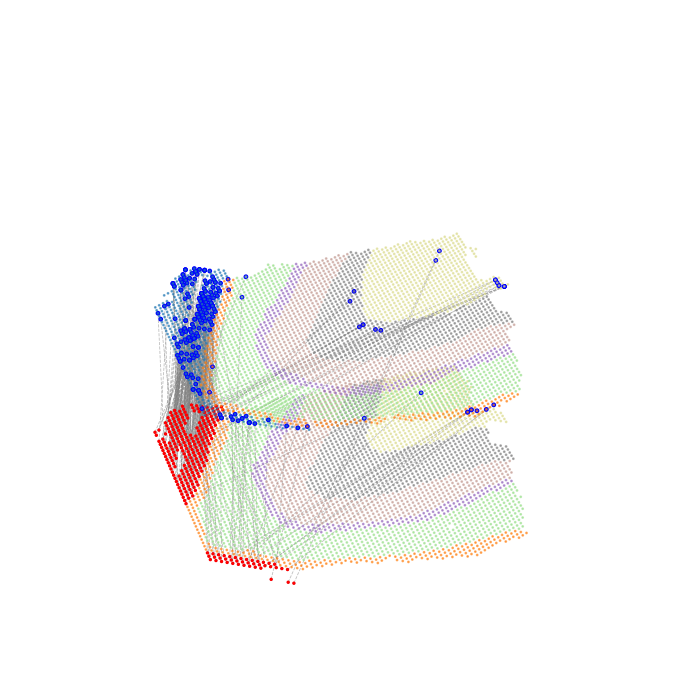

In [16]:
blue_points,endpoint_cell_types=plot_matching_flow(
    adata1_df, adata2_df, matching, selected_cell_type='Layer_1', 
    arrow_sample_size_per_type=355, xlim=(-0.1, 1.1), ylim=(-0.1, 1.1), height_scale=1.0, #save_path='/home/dbj/lib_3d_OT/revise/cross2/brain.png'
)

In [17]:
layer_1_points = adata1_df[adata1_df['celltype'] == 'Layer_1'][['x', 'y']].values
chamfer_dist = chamfer_distance(blue_points, layer_1_points)

print(f"Chamfer distance : {chamfer_dist}")

Chamfer distance : 0.033967625300809


In [18]:
final_type = ['Layer_1']
CI_score = calculate_prediction_accuracy(endpoint_cell_types, final_type)
CI_score

0.8754578754578755

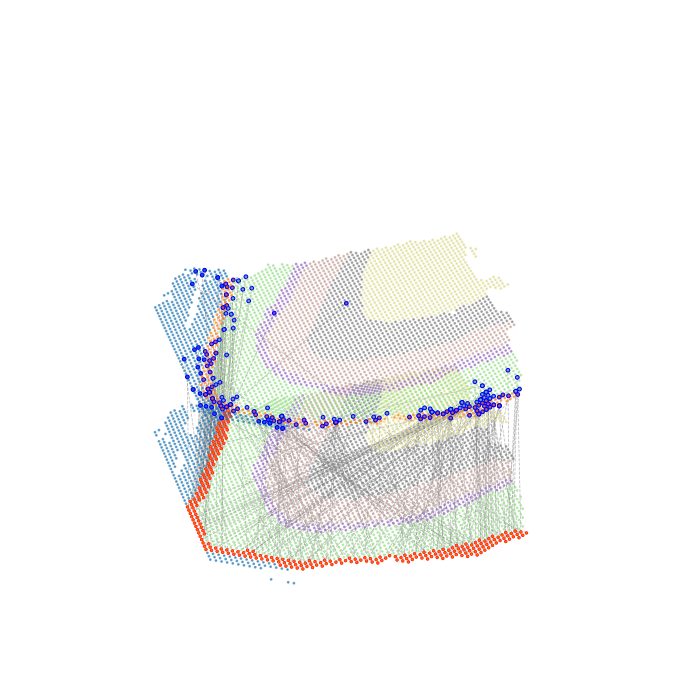

In [19]:
blue_points,endpoint_cell_types=plot_matching_flow(
    adata1_df, adata2_df, matching, selected_cell_type='Layer_2', 
    arrow_sample_size_per_type=355, xlim=(-0.1, 1.1), ylim=(-0.1, 1.1), height_scale=1.0, #save_path='/home/dbj/lib_3d_OT/revise/cross2/brain.png'
)

In [20]:
layer_1_points = adata1_df[adata1_df['celltype'] == 'Layer_2'][['x', 'y']].values
chamfer_dist = chamfer_distance(blue_points, layer_1_points)

print(f"Chamfer distance : {chamfer_dist}")

Chamfer distance : 0.0013521322241733886


In [21]:
final_type = ['Layer_2']
CI_score = calculate_prediction_accuracy(endpoint_cell_types, final_type)
CI_score

0.4980237154150198